#### Teoría de los Circuitos 2
# Trabajo semanal 7
#### Leandro Robledo

Dado el siguiente esquema:

![Esquema_biquad](Esquema_biquad.PNG)

Se pide:

1. Comprobar que el esquema se corresponde con la siguiente transferencia:
$H_{(z)}=(1-C1 Z^{-N})*\frac{b0+b1.Z^{-1}+b2.Z^{-2}}{1/a0-a1.Z^{-1}-a2.Z^{-2}}$

2. Filtro de media móvil ( moving average ó CIC: cascaded integrator comb )

Verificar la transferencia para $a0$ = 1, $a1$ = 1, $b0$ = 1/𝑁, $C1$ = 1  y  N = 3, 4 𝑦 5

¿Es un filtro IIR o FIR ? Discuta las ventajas que tendría esta implementación respecto al filtro FIR de media móvil 3. 

¿Podría implementar el siguiente sistema $h(k)$ = (1, 1, 1, 1, 1, 1, 1) con esta topología ?

3. Filtro diferenciador ( differentiator )

Obtener los valores de $a_i$ y $b_k$ para obtener $Y(n)$= [$X(n)-X(n-2)$ ] / 2 

Evaluar al sistema con un seno discreto en python y comprobar si la salida se aproxima a la derivada.

4. Filtro elimina continua ( DC Blocker )

Verifique la transferencia para $a0$ = 1, $a1= \beta$, $b0$ = 1 , $b1$= -1 para $\beta=0.9$

Determine $\beta$ para que la transferencia en $\Omega =0.1 \pi$ sea 3 dB menor a la transferencia en  $\Omega =\pi$ 
 
5. Filtro Peine  ( Comb filter )

Verifique la transferencia para $c1$ = -1 y N=8 

Proponga una $f_sampling$ y halle las frecuencias donde se generan los peaks y los nulls en el espectro.

Importante: Para los siguientes incisos calcular y representar sus singularidades en el plano $z$, su Respuesta de módulo y fase de 
$H(z)$ y su diagrama en bloques. Cuando no se indique considerar los coeficientes igual a cero.

Bonus

🥉 Verificar en Python el punto 3) con la función diff 
🥉 Utilizando solo el biquad, hallar los valores de los coeficientes para emular la respuesta analógica de un pasatodo de orden 1. Utilice alguno de los métodos de diseño vistos en clases. 


## 1)Transferencia del sistema:
Para encontrar la transferencia fue renombrando subpartes del sistema para luego utilizarlas como ecuaciones y despejar hasta llegar a la expresion pedida:
![Transferencia_despeje](Transferencia_despeje.jpeg)


#### Filtro Media Movil<a id="MAI_Pyton"></a>



![Filtro_media_movil](Filtro_media_movil.jpeg)

El filtro si bien por la primera forma de escribir pareciera que tiene un polo fuera del origen, una vez replanteado extrayendo como factor comun $Z^{-N}$ se encuentra con un filtro FIR ya que solo depende de los coeficientes de b. 

La ventaja que tiene sobre un filtro de media movil convencional, es que no se necesita agrandar el numero de cuentas en N segun la cantidad de muestras que se quieran promediar gracias al integrador que se incluye.

Para obtener esta salida ante la respuesta al impulso se debe de modificar $b0=1$ y $C1=7$ de forma que el promedio no resulte atenuado por la media del sistema y poder obtener la salida $h[k]=(1,1,1,1,1,1,1)$. De esta forma el filtro quedaria tal que: $H(z)=\frac{1-Z^{-7}}{1-Z^{-1}}$


![Media_Movil_mod_fase](Media_Movil_mod_fase.jpeg)




### Filtro Diferenciador 

![Filtro_derivador](Filtro_derivador.jpeg)

Diferencia máxima entre método con diff y método manual: 1.39e-17
Gráfico guardado como: diferenciador_con_diff.png


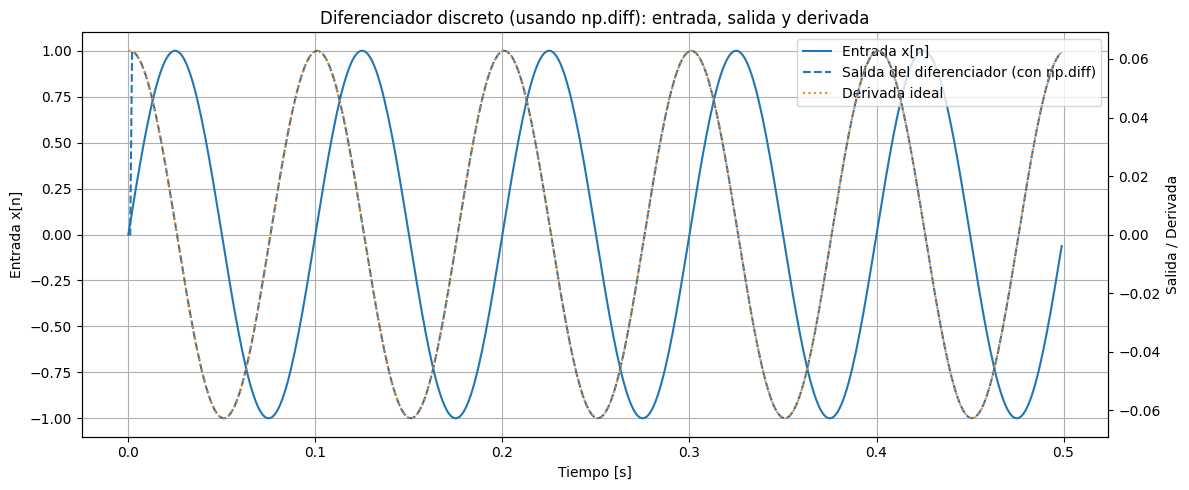

Frecuencia de muestreo: 1000 Hz
Frecuencia del seno: 10 Hz
Frecuencia angular discreta: 0.062832 rad/muestra
Error RMS: 2.916871e-05


In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARÁMETROS
# ============================================================

Fs = 1000              # Frecuencia de muestreo [Hz]
f = 10                 # Frecuencia del seno [Hz]

N_muestras = 500

n = np.arange(N_muestras)
t = n / Fs

# Frecuencia angular discreta
omega = 2 * np.pi * f / Fs


# ============================================================
# SEÑAL DE ENTRADA
# x[n] = sin(omega*n)
# ============================================================

x = np.sin(omega * n)

# ============================================================
# DIFERENCIADOR usando np.diff
#
# y[n] = (x[n] - x[n-2]) / 2
#
# np.diff(x) calcula d[i] = x[i+1] - x[i]  (primera diferencia,
# longitud N-1). No da directamente un salto de 2 muestras, pero
# sumando dos diferencias consecutivas obtenemos justamente eso:
#
#   x[n] - x[n-2] = (x[n] - x[n-1]) + (x[n-1] - x[n-2])
#                 =        d[n-1]   +        d[n-2]
#
# Entonces, para n = 2, 3, ..., N-1:
#   y[n] = ( d[n-1] + d[n-2] ) / 2
# ============================================================

d = np.diff(x)          # d[i] = x[i+1] - x[i], i = 0..N-2  (longitud N-1)

y = np.zeros_like(x)
y[2:] = (d[1:] + d[:-1]) / 2   # d[1:] = d[n-1], d[:-1] = d[n-2]  para n=2..N-1

# ---- Verificación: debe dar exactamente lo mismo que el método anterior ----
y_manual = np.zeros_like(x)
y_manual[2:] = (x[2:] - x[:-2]) / 2
error_metodo = np.max(np.abs(y - y_manual))
print(f"Diferencia máxima entre método con diff y método manual: {error_metodo:.2e}")
assert error_metodo < 1e-12, "Los dos métodos no coinciden"


# ============================================================
# DERIVADA IDEAL
#
# dx/dn = omega*cos(omega*n)
#
# La salida del diferenciador queda desplazada una muestra,
# por eso usamos (n-1) para compararla correctamente.
# ============================================================

derivada_ideal = omega * np.cos(omega * (n - 1))


# ============================================================
# GRÁFICO
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 5))

# Señal de entrada
ax1.plot(t, x, label='Entrada x[n]')

ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Entrada x[n]')
ax1.grid()

# Segundo eje para salida y derivada
ax2 = ax1.twinx()

ax2.plot(t, y, '--', label='Salida del diferenciador (con np.diff)')
ax2.plot(t, derivada_ideal, ':', label='Derivada ideal')

ax2.set_ylabel('Salida / Derivada')

# Leyenda combinada
lineas1, etiquetas1 = ax1.get_legend_handles_labels()
lineas2, etiquetas2 = ax2.get_legend_handles_labels()

ax1.legend(
    lineas1 + lineas2,
    etiquetas1 + etiquetas2,
    loc='upper right'
)

plt.title('Diferenciador discreto (usando np.diff): entrada, salida y derivada')
plt.tight_layout()
plt.savefig('diferenciador_con_diff.png', dpi=150)
print("Gráfico guardado como: diferenciador_con_diff.png")
plt.show()


# ============================================================
# ERROR RMS
# ============================================================

error = y[2:] - derivada_ideal[2:]

error_rms = np.sqrt(np.mean(error**2))

print(f'Frecuencia de muestreo: {Fs} Hz')
print(f'Frecuencia del seno: {f} Hz')
print(f'Frecuencia angular discreta: {omega:.6f} rad/muestra')
print(f'Error RMS: {error_rms:.6e}')

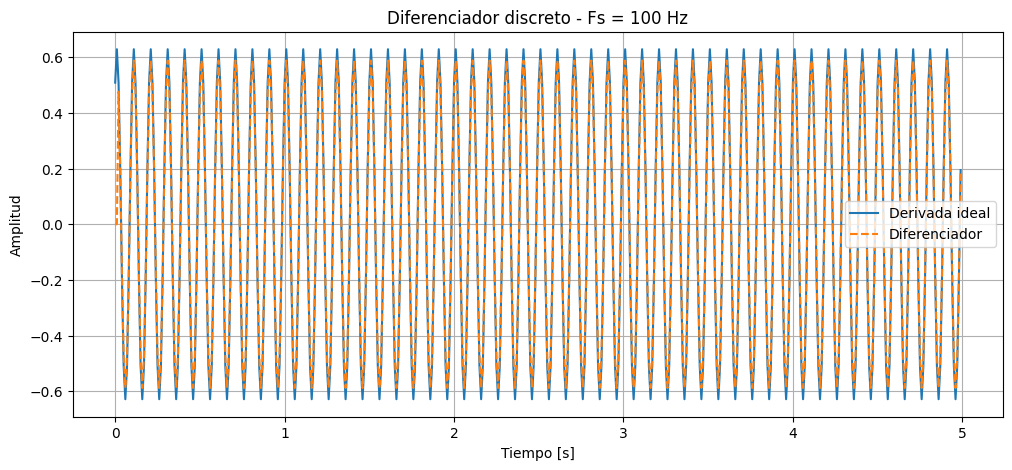

Fs = 100 Hz
Frecuencia del seno = 10 Hz
omega = 0.628319 rad/muestra
Error RMS = 2.862366e-02
--------------------------------------------------


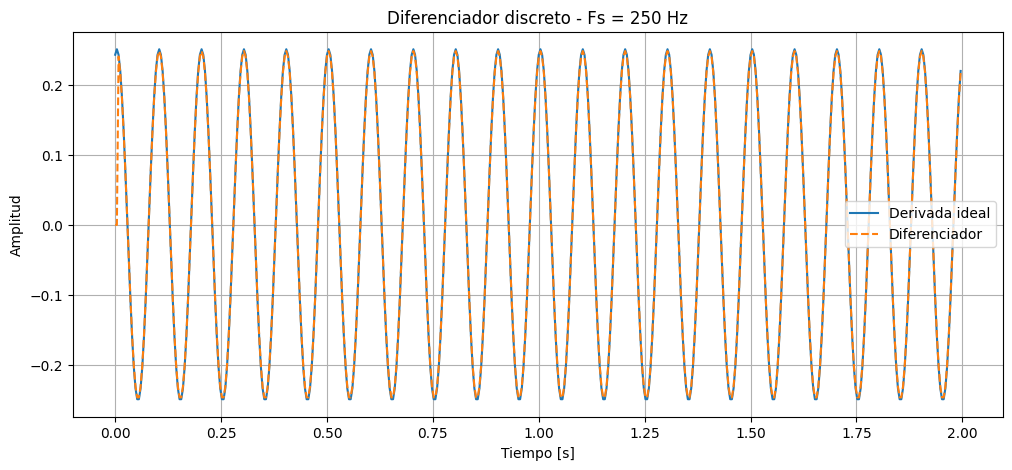

Fs = 250 Hz
Frecuencia del seno = 10 Hz
omega = 0.251327 rad/muestra
Error RMS = 1.861495e-03
--------------------------------------------------


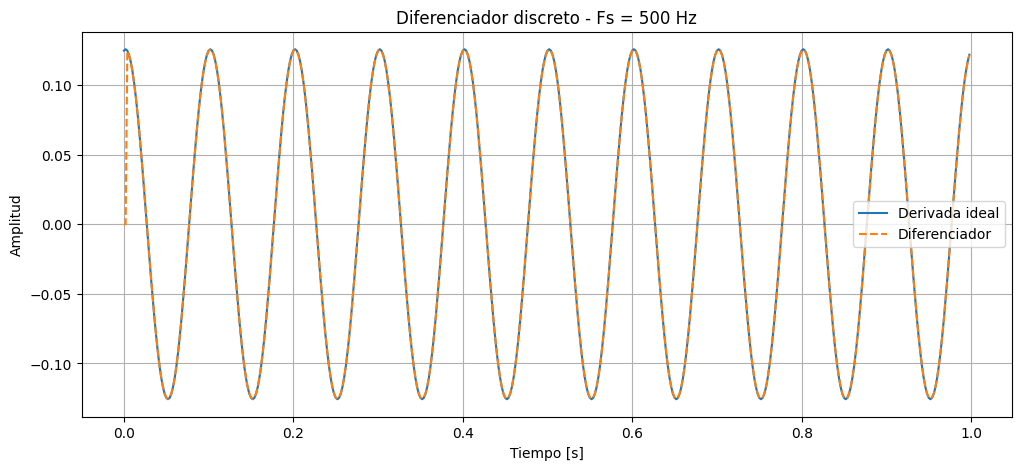

Fs = 500 Hz
Frecuencia del seno = 10 Hz
omega = 0.125664 rad/muestra
Error RMS = 2.332171e-04
--------------------------------------------------


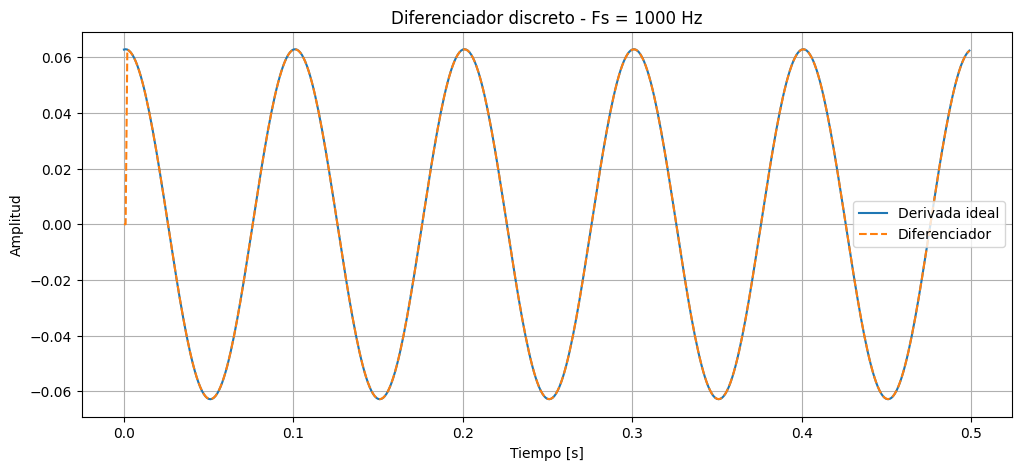

Fs = 1000 Hz
Frecuencia del seno = 10 Hz
omega = 0.062832 rad/muestra
Error RMS = 2.916871e-05
--------------------------------------------------


In [9]:
# ============================================================
# PARÁMETROS
# ============================================================

f = 10                   # Frecuencia del seno [Hz]

N = 4                    # Cantidad de señales a analizar

# Frecuencias de muestreo
Fs_vector = np.array([100, 250, 500, 1000])

# Cantidad de muestras de cada señal
N_muestras = 500


# ============================================================
# VERIFICACIÓN
# ============================================================

if len(Fs_vector) != N:
    raise ValueError(
        f"Fs_vector debe tener exactamente {N} elementos"
    )


# ============================================================
# ANÁLISIS PARA CADA Fs
# ============================================================

for i in range(N):

    Fs = Fs_vector[i]

    # Índice de las muestras
    n = np.arange(N_muestras)

    # Tiempo
    t = n / Fs

    # Frecuencia angular discreta
    omega = 2 * np.pi * f / Fs


    # ========================================================
    # SEÑAL DE ENTRADA
    # ========================================================

    x = np.sin(omega * n)


    # ========================================================
    # DIFERENCIADOR
    #
    # y[n] = (x[n] - x[n-2]) / 2
    # ========================================================

    y = np.zeros_like(x)

    y[2:] = (x[2:] - x[:-2]) / 2


    # ========================================================
    # DERIVADA IDEAL
    #
    # La salida del diferenciador está desplazada una muestra.
    # ========================================================

    derivada_ideal = omega * np.cos(omega * (n - 1))


    # ========================================================
    # ERROR RMS
    # ========================================================

    error = y[2:] - derivada_ideal[2:]

    error_rms = np.sqrt(np.mean(error**2))


    # ========================================================
    # GRÁFICO
    # ========================================================

    plt.figure(figsize=(12, 5))

    plt.plot(
        t,
        derivada_ideal,
        label='Derivada ideal'
    )

    plt.plot(
        t,
        y,
        '--',
        label='Diferenciador'
    )

    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')

    plt.title(
        f'Diferenciador discreto - Fs = {Fs} Hz'
    )

    plt.grid()
    plt.legend()

    plt.show()


    # ========================================================
    # RESULTADOS
    # ========================================================

    print(f'Fs = {Fs} Hz')
    print(f'Frecuencia del seno = {f} Hz')
    print(f'omega = {omega:.6f} rad/muestra')
    print(f'Error RMS = {error_rms:.6e}')
    print('-' * 50)


Se puede observar como a medida que la fs aumaenta, aumenta el error de la derivada respecto de la ideal y esto se debe a que la formula
resultante en este caso es $y[n]=sin(\omega)cos(\omega(n−1))$, donde $sin(\omega) \cong \omega$ si $ \omega \Rightarrow 0$ 

## Filtro DC blocker 


![DC_blocker](DC_blocker.jpeg)

#### Filtro peine


![Filtro_peine](Filtro_peine.jpeg)

Coeficientes b: [1. 0. 0. 0. 0. 0. 0. 0. 1.]

Error máximo entre cálculo directo y fórmula teórica: 4.58e-16
-> La fórmula teórica |H(Omega)| = 2|cos(4*Omega)| queda verificada.

Frecuencia de muestreo propuesta: fs = 8000 Hz

k | Omega_peak [rad] | f_peak [Hz] | Omega_null [rad] | f_null [Hz]
0 |     0.0000      |       0.0   |     0.3927      |     500.0
1 |     0.7854      |    1000.0   |     1.1781      |    1500.0
2 |     1.5708      |    2000.0   |     1.9635      |    2500.0
3 |     2.3562      |    3000.0   |     2.7489      |    3500.0
4 |     3.1416      |    4000.0   |     3.5343      |    4500.0
5 |     3.9270      |    5000.0   |     4.3197      |    5500.0
6 |     4.7124      |    6000.0   |     5.1051      |    6500.0
7 |     5.4978      |    7000.0   |     5.8905      |    7500.0

Verificación:
  |H| en peaks (debe ser 2): [2. 2. 2. 2. 2. 2. 2. 2.]
  |H| en nulls (debe ser 0): [0. 0. 0. 0. 0. 0. 0. 0.]


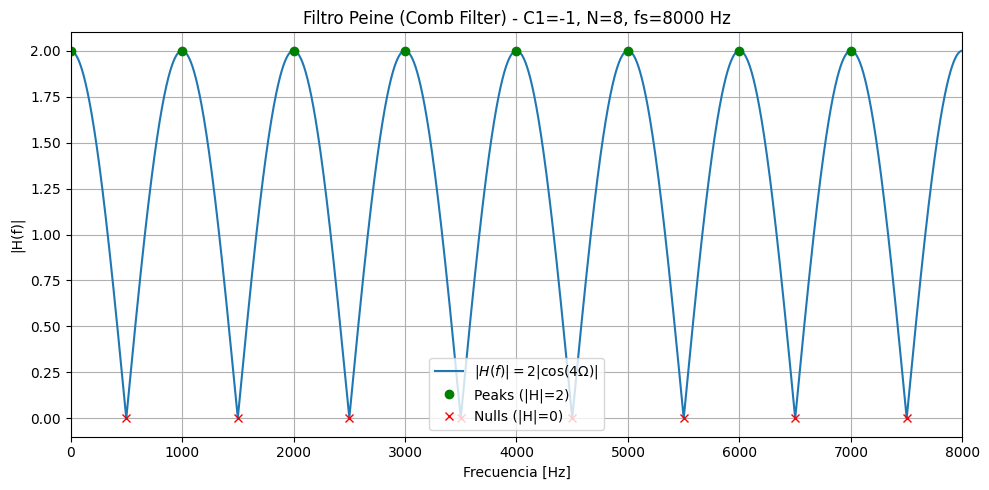

In [11]:
"""
Verificación del Filtro Peine (Comb Filter)
H(z) = 1 - C1 * z^-N   con C1 = -1, N = 8  =>  H(z) = 1 + z^-8

Se verifica:
  1) |H(Omega)| = 2*|cos(4*Omega)|  (fórmula teórica derivada)
  2) Ubicación de peaks y nulls, tanto en Omega [rad] como en f [Hz]
  3) Comparación numérica entre la FFT/evaluación directa y la fórmula teórica
"""

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Parámetros del filtro
# ---------------------------------------------------------
C1 = -1
N = 8
fs = 8000  # Hz, frecuencia de muestreo propuesta

# Coeficientes del FIR: H(z) = 1 - C1*z^-N = 1 + z^-8
b = np.zeros(N + 1)
b[0] = 1
b[N] = -C1          # -(-1) = 1
a = [1]              # sin parte recursiva (solo el peine)

print("Coeficientes b:", b)

# ---------------------------------------------------------
# 2. Respuesta en frecuencia: cálculo directo vs fórmula teórica
# ---------------------------------------------------------
Omega = np.linspace(0, 2 * np.pi, 4000)

# Cálculo directo: H(e^jOmega) = sum b[n] * e^{-j n Omega}
n = np.arange(len(b))
H_directo = np.array([np.sum(b * np.exp(-1j * n * w)) for w in Omega])

# Fórmula teórica derivada: H(Omega) = 2*cos(4*Omega)*e^{-j4*Omega}
H_teorico = 2 * np.cos(4 * Omega) * np.exp(-1j * 4 * Omega)

error_max = np.max(np.abs(H_directo - H_teorico))
print(f"\nError máximo entre cálculo directo y fórmula teórica: {error_max:.2e}")
assert error_max < 1e-10, "La fórmula teórica no coincide con el cálculo directo"
print("-> La fórmula teórica |H(Omega)| = 2|cos(4*Omega)| queda verificada.")

# ---------------------------------------------------------
# 3. Peaks y nulls teóricos
# ---------------------------------------------------------
k = np.arange(0, N)  # k = 0..N-1 cubre todo [0, 2pi)

Omega_peaks = k * np.pi / 4
Omega_nulls = np.pi / 8 + k * np.pi / 4

f_peaks = k * fs / N
f_nulls = fs / (2 * N) + k * fs / N

print(f"\nFrecuencia de muestreo propuesta: fs = {fs} Hz\n")
print("k | Omega_peak [rad] | f_peak [Hz] | Omega_null [rad] | f_null [Hz]")
for i in range(N):
    print(f"{i} |     {Omega_peaks[i]:.4f}      |   {f_peaks[i]:7.1f}   |"
          f"     {Omega_nulls[i]:.4f}      |   {f_nulls[i]:7.1f}")

# ---------------------------------------------------------
# 4. Verificación numérica: |H| en peaks debe ser 2, en nulls debe ser 0
# ---------------------------------------------------------
H_en_peaks = np.abs(2 * np.cos(4 * Omega_peaks))
H_en_nulls = np.abs(2 * np.cos(4 * Omega_nulls))

print("\nVerificación:")
print("  |H| en peaks (debe ser 2):", np.round(H_en_peaks, 6))
print("  |H| en nulls (debe ser 0):", np.round(np.abs(H_en_nulls), 10))

# ---------------------------------------------------------
# 5. Gráfico de |H(f)| con peaks y nulls marcados
# ---------------------------------------------------------
f = Omega * fs / (2 * np.pi)

plt.figure(figsize=(10, 5))
plt.plot(f, np.abs(H_directo), label=r'$|H(f)|=2|\cos(4\Omega)|$')
plt.plot(f_peaks, H_en_peaks, 'go', label='Peaks (|H|=2)')
plt.plot(f_nulls, np.zeros_like(f_nulls), 'rx', label='Nulls (|H|=0)')
plt.title(f"Filtro Peine (Comb Filter) - C1=-1, N={N}, fs={fs} Hz")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("|H(f)|")
plt.xlim(0, fs)
plt.grid(True)
plt.legend()
plt.tight_layout()

### Bonus Modulo y fase de todos los filtros  


![Pasa_todo](Pasa_todo.jpeg)

  Nulls detectados en media movil 3: 2667.0Hz
Gráfico guardado como: media_movil_3_fase.png


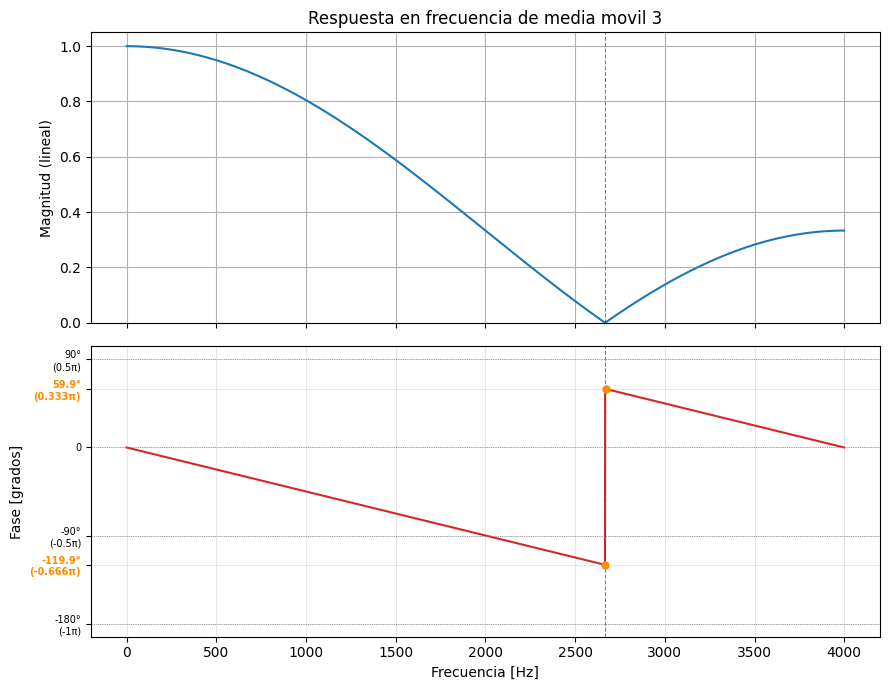

  Nulls detectados en media movil 4: 2000.0Hz, 3999.0Hz
Gráfico guardado como: media_movil_4_fase.png


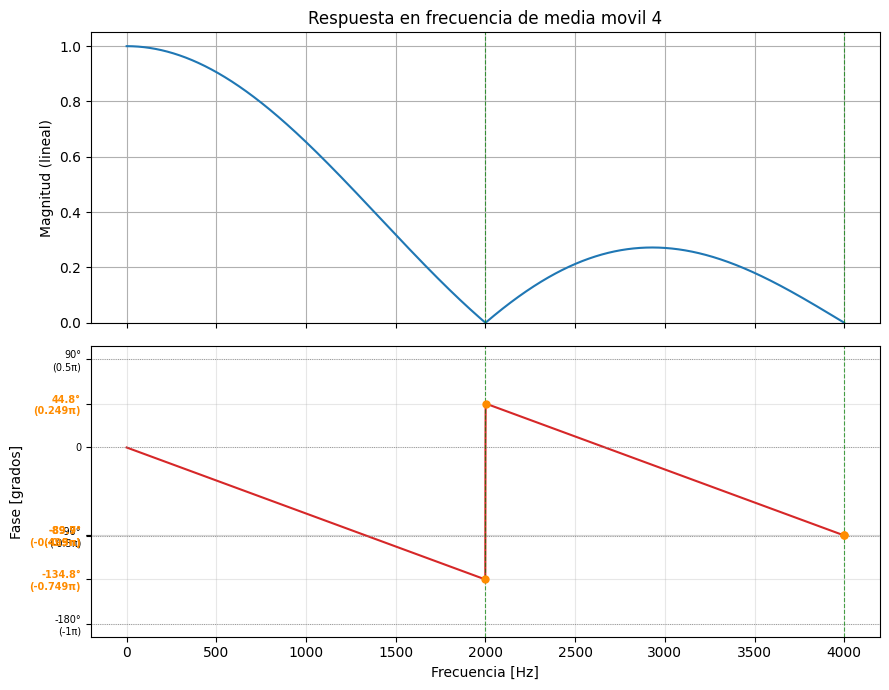

  Nulls detectados en media movil 5: 1599.6Hz, 3200.2Hz
Gráfico guardado como: media_movil_5_fase.png


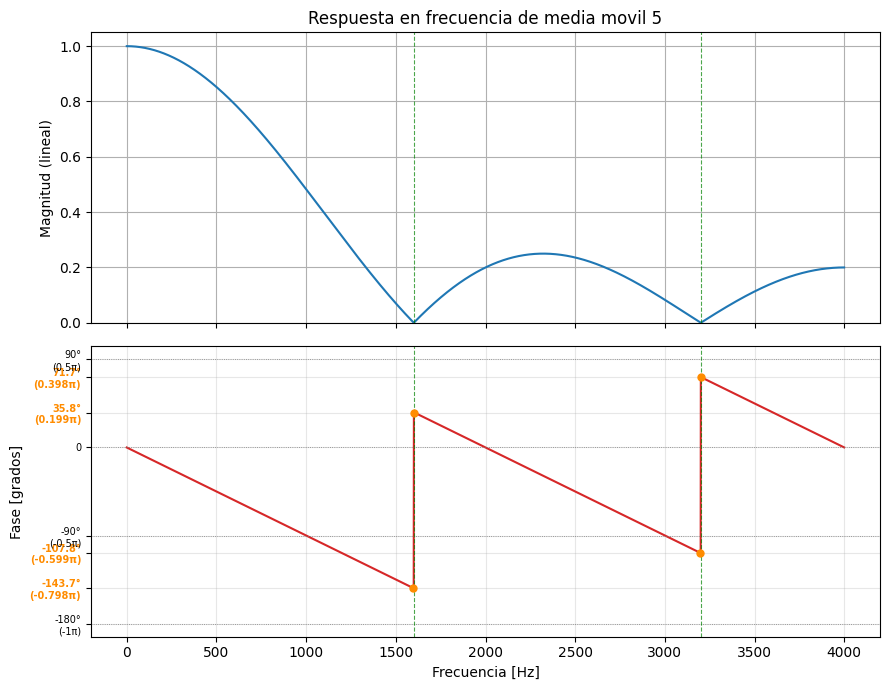

  Nulls detectados en diferenciador: 1.0Hz, 3999.0Hz
Gráfico guardado como: diferenciador_fase.png


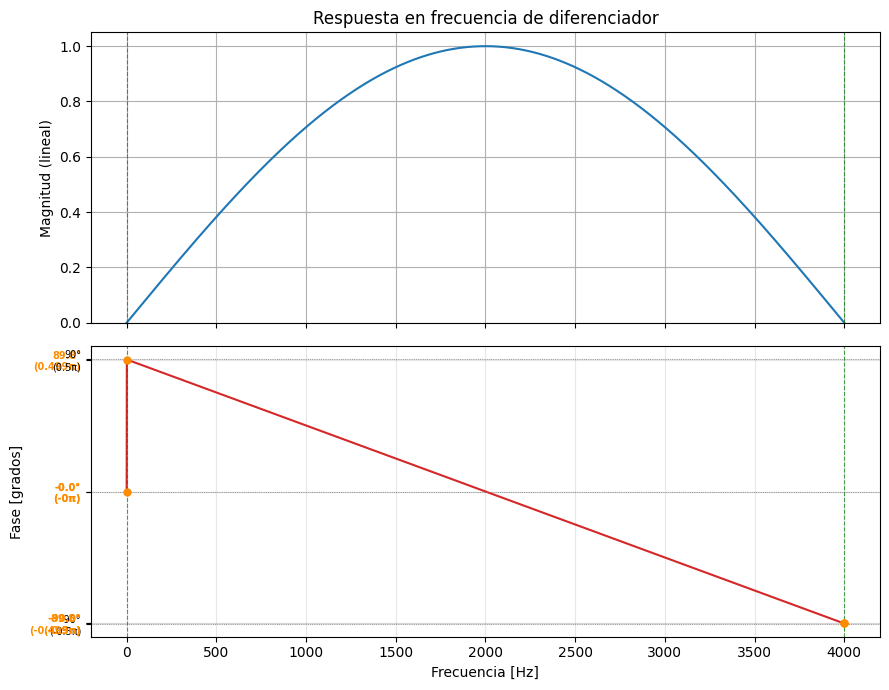

  Nulls detectados en DC Blocker (beta=0.7265): 0.0Hz
Gráfico guardado como: DC_Blocker_beta=0.7265_fase.png


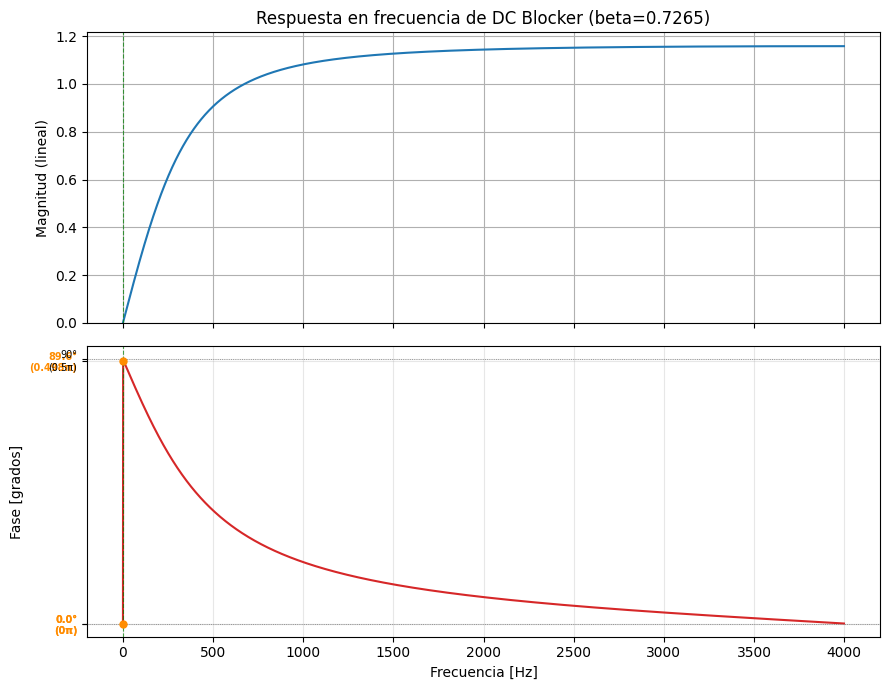

  Nulls detectados en Comb Filter (N=8): 500.0Hz, 1500.0Hz, 2500.0Hz, 3500.0Hz
Gráfico guardado como: Comb_Filter_N=8_fase.png


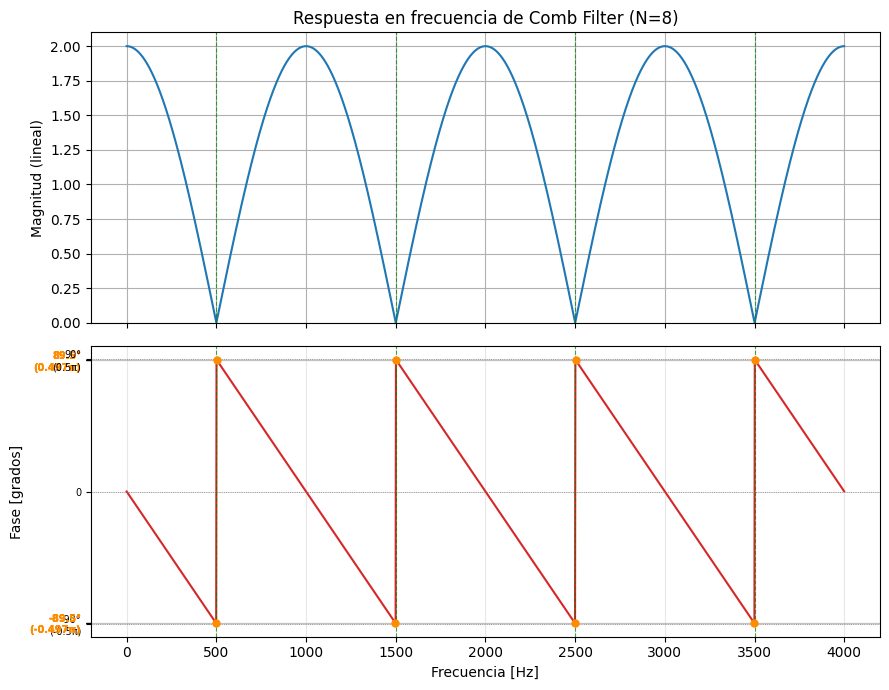

In [27]:
"""
Graficador de Respuesta en Frecuencia (Magnitud y Fase) para H(z)
-------------------------------------------------------------------
Sirve para cualquier transferencia racional en z de la forma:

        b0 + b1*z^-1 + b2*z^-2 + ...
H(z) = -------------------------------
        a0 + a1*z^-1 + a2*z^-2 + ...

Solo hay que cargar los coeficientes b y a como listas/arrays.
Usa scipy.signal.freqz, que evalúa H(e^jOmega) numéricamente.
"""

import numpy as np
from scipy.signal import freqz
import matplotlib.pyplot as plt


def graficar_respuesta(b, a, fs=None, titulo="H(z)", unwrap_fase=True,
                        worN=4096, escala_magnitud="lineal",
                        marcar_notables=True, tol_cero=1e-3):
    """
    Grafica magnitud y fase (grados) de H(z) = B(z)/A(z).

    Parámetros
    ----------
    b : array_like
        Coeficientes del numerador [b0, b1, b2, ...]
    a : array_like
        Coeficientes del denominador [a0, a1, a2, ...]
    fs : float o None
        Frecuencia de muestreo en Hz. Si es None, el eje x queda en
        radianes/muestra (Omega). Si se especifica, el eje x queda en Hz.
    titulo : str
        Título del gráfico.
    unwrap_fase : bool
        Si True, "desenvuelve" la fase para evitar saltos de +-180°.
    worN : int
        Cantidad de puntos de frecuencia a evaluar.
    escala_magnitud : str
        "lineal" -> grafica |H(Omega)| tal cual (0 a max, sin dB).
        "db"     -> grafica 20*log10(|H(Omega)|) (puede irse a -inf en nulls).
    marcar_notables : bool
        Si True: pone ticks en el eje de fase cada 90° (0, ±90, ±180, ...)
        y marca con líneas verticales punteadas las frecuencias donde
        la magnitud pasa por (o muy cerca de) cero, ya que ahí es donde
        ocurren los saltos de fase de 180° en los FIR de fase lineal.
    tol_cero : float
        Umbral relativo (respecto al máximo de |H|) para considerar que
        la magnitud "toca cero" en un punto, y así detectar los nulls.
    """
    # w: frecuencias angulares evaluadas, h: H(e^jw) complejo
    w, h = freqz(b, a, worN=worN, fs=fs if fs else 2 * np.pi)

    magnitud_lineal = np.abs(h)
    fase = np.angle(h)
    if unwrap_fase:
        fase = np.unwrap(fase)
    fase_grados = np.degrees(fase)

    fig, (ax_mag, ax_fase) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    # --- Magnitud ---
    if escala_magnitud == "db":
        magnitud_db = 20 * np.log10(magnitud_lineal + 1e-12)
        ax_mag.plot(w, magnitud_db, color='tab:blue')
        ax_mag.set_ylabel("Magnitud [dB]")
    else:
        ax_mag.plot(w, magnitud_lineal, color='tab:blue')
        ax_mag.set_ylabel("Magnitud (lineal)")
        ax_mag.set_ylim(bottom=0)  # arranca en 0, no en negativo

    ax_mag.set_title(f"Respuesta en frecuencia de {titulo}")
    ax_mag.grid(True)

    # --- Fase ---
    ax_fase.plot(w, fase_grados, color='tab:red')
    ax_fase.set_ylabel("Fase [grados]")
    ax_fase.grid(True, alpha=0.3)

    if fs:
        ax_fase.set_xlabel("Frecuencia [Hz]")
    else:
        ax_fase.set_xlabel(r"$\Omega$ [rad/muestra]")

    if marcar_notables:
        # --- Ticks del eje Y cada 90°, cubriendo el rango real de la fase ---
        paso = 90
        ymin = np.floor(fase_grados.min() / paso) * paso
        ymax = np.ceil(fase_grados.max() / paso) * paso
        yticks = np.arange(ymin, ymax + paso, paso)
        ax_fase.set_yticks(yticks)
        # Etiquetas mostrando también el equivalente en radianes (fracción de pi)
        etiquetas = []
        for y in yticks:
            frac = y / 180  # y = frac * 180 => y en grados; frac*pi en radianes
            if frac == 0:
                etiquetas.append("0")
            else:
                etiquetas.append(f"{y:.0f}°\n({frac:.2g}π)")
        ax_fase.set_yticklabels(etiquetas, fontsize=8)

        # Líneas horizontales de referencia en cada múltiplo de 90°
        for y in yticks:
            ax_fase.axhline(y, color='gray', linestyle=':', linewidth=0.6)

        # --- Detectar nulls de magnitud, marcarlos, y anotar el valor
        #     EXACTO de fase justo antes/después del cruce ---
        max_mag = magnitud_lineal.max()
        idx_ceros = np.where(magnitud_lineal < tol_cero * max_mag)[0]

        yticks_extra = []      # valores exactos de fase a marcar en el eje Y
        etiquetas_extra = []

        if len(idx_ceros) > 0:
            grupos = np.split(idx_ceros, np.where(np.diff(idx_ceros) > 1)[0] + 1)
            frecs_nulls = [w[g[len(g) // 2]] for g in grupos]

            for g, wc in zip(grupos, frecs_nulls):
                ax_mag.axvline(wc, color='green', linestyle='--', linewidth=0.8, alpha=0.7)
                ax_fase.axvline(wc, color='green', linestyle='--', linewidth=0.8, alpha=0.7)

                # Tomamos un punto justo antes y justo después del grupo de
                # índices que forman el null, para capturar la fase real
                # de cada lado del salto (evitando el punto exacto del cero,
                # que numéricamente es ambiguo).
                i_centro = g[len(g) // 2]
                i_antes = max(i_centro - 3, 0)
                i_despues = min(i_centro + 3, len(fase_grados) - 1)

                for i_pt in (i_antes, i_despues):
                    val = fase_grados[i_pt]
                    yticks_extra.append(val)
                    frac_pi = val / 180
                    etiquetas_extra.append(f"{val:.1f}°\n({frac_pi:.3g}π)")

                    # Marca puntual en el gráfico de fase, resaltando el valor
                    ax_fase.plot(w[i_pt], val, 'o', color='darkorange',
                                 markersize=5, zorder=5)

            print(f"  Nulls detectados en {titulo}: "
                  + ", ".join(f"{wc:.1f}" + ("Hz" if fs else "rad") for wc in frecs_nulls))

        # --- Combinar ticks de 90° con los ticks exactos de los saltos ---
        yticks_todos = list(yticks) + yticks_extra
        etiquetas_todas = etiquetas + etiquetas_extra
        # Ordenar ambos en conjunto según el valor del tick
        orden = np.argsort(yticks_todos)
        yticks_todos = np.array(yticks_todos)[orden]
        etiquetas_todas = [etiquetas_todas[i] for i in orden]

        ax_fase.set_yticks(yticks_todos)
        ax_fase.set_yticklabels(etiquetas_todas, fontsize=7)
        # Resaltar en color los ticks que son valores exactos de salto
        for lbl, val in zip(ax_fase.get_yticklabels(), yticks_todos):
            if val in yticks_extra:
                lbl.set_color('darkorange')
                lbl.set_fontweight('bold')

    plt.tight_layout()
    nombre_archivo = f"{titulo.replace(' ', '_').replace('(', '').replace(')', '')}_fase.png"
    plt.savefig(nombre_archivo, dpi=150)
    print(f"Gráfico guardado como: {nombre_archivo}")
    plt.show()

    return w, h


# =====================================================================
# EJEMPLOS DE USO: las dos transferencias que veníamos trabajando
# =====================================================================
if __name__ == "__main__":

    fs = 8000  # Hz

    # -------------------------------------------------------------
    # PARA USAR CON TU PROPIA TRANSFERENCIA:
    # Simplemente definí b y a con tus coeficientes y llamá a la función:
    #
    #   b = [b0, b1, b2, ...]
    #   a = [a0, a1, a2, ...]
    #   graficar_respuesta(b, a, fs=8000, titulo="Mi filtro")
    # -------------------------------------------------------------

    # -------------------------------------------------------------
    # 1) Media Movil 3:  H(z) = 1/N*(1 + z^-3)/(1 + z^-1)   
    # -------------------------------------------------------------

    b = [1, 1, 1]
    a = [3]
    graficar_respuesta(b, a, fs=fs, titulo="media movil 3")

    # -------------------------------------------------------------
    # 2) Media Movil 4:  H(z) = 1/N*(1 + z^-4)/(1 + z^-1)   
    # -------------------------------------------------------------
    b = [1, 1, 1, 1]
    a = [4]
    graficar_respuesta(b, a, fs=fs, titulo="media movil 4")
    
    # -------------------------------------------------------------
    # 3) Media Movil 5:  H(z) = 1/N*(1 + z^-5)/(1 + z^-1)   
    # -------------------------------------------------------------

    b = [1, 1, 1, 1, 1]
    a = [5]
    graficar_respuesta(b, a, fs=fs, titulo="media movil 5")

    # -------------------------------------------------------------
    # 4) Derivador:  H(z) = 1 + z^-2)/2   
    # -------------------------------------------------------------

    b = [1, 0, -1]
    a = [2]
    graficar_respuesta(b, a, fs=fs, titulo="diferenciador")

    # -------------------------------------------------------------
    # 5) DC Blocker:  H(z) = (1 - z^-1) / (1 - beta*z^-1)
    # -------------------------------------------------------------
    beta = 0.7265
    b_dc = [1, -1]          # b0=1, b1=-1
    a_dc = [1, -beta]       # a0=1, a1=-beta
    graficar_respuesta(b_dc, a_dc, fs=fs, titulo="DC Blocker (beta=0.7265)")

    # -------------------------------------------------------------
    # 6) Comb Filter:  H(z) = 1 + z^-8   (C1=-1, N=8)
    # -------------------------------------------------------------
    N = 8
    C1 = -1
    b_comb = np.zeros(N + 1)
    b_comb[0] = 1
    b_comb[N] = -C1
    a_comb = [1]
    graficar_respuesta(b_comb, a_comb, fs=fs, titulo="Comb Filter (N=8)")
